In [7]:
# ===============================================
# TASK 1: FEATURE ENGINEERING
# ===============================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.pyplot as plt
import zipfile

# -------- Load data from ZIP (Deliverable 2 is independent) --------
DATA_PATH = "./online_retail_II.csv.zip"

if DATA_PATH.endswith(".zip"):
    with zipfile.ZipFile(DATA_PATH) as z:
        csv_name = z.namelist()[0]  # first CSV inside the zip
        with z.open(csv_name) as f:
            df = pd.read_csv(f, encoding="utf-8", low_memory=False)
else:
    df = pd.read_csv(DATA_PATH, encoding="utf-8", low_memory=False)

# Make output nicer in notebook
pd.set_option("display.max_columns", 50)

# -------- Normalize column names so we can reliably find them --------
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
print("Columns after normalization:\n", df.columns.tolist())

# We now expect something like 'invoice', 'invoice_no', or 'invoiceno'
# and 'quantity', 'price', 'invoicedate', etc.

# -------- Basic cleanup needed for feature engineering --------
# Convert quantity and price to numeric (in case of weird types)
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Drop rows where critical fields are missing
df = df.dropna(subset=["quantity", "price"])

# Keep only positive quantity and price
df = df[(df["quantity"] > 0) & (df["price"] > 0)]

# Create line_total = quantity * price (Deliverable 2 is standalone)
df["line_total"] = df["quantity"] * df["price"]

# -------- 1.1 Keep only positive purchases (no returns or free lines) --------
df_model = df.copy()

df_model = df_model[df_model["quantity"] > 0]
df_model = df_model[df_model["line_total"] > 0]

print("Shape after filtering positive purchases:", df_model.shape)

# -------- 1.2 Aggregate to invoice level (one row per invoice) --------
invoice_col = None

# Look for any reasonable invoice column name in normalized columns
for cand in ["invoiceno", "invoice", "invoice_no"]:
    if cand in df_model.columns:
        invoice_col = cand
        break

# If still None, show columns so you can see what it's really called
if invoice_col is None:
    print("Could not auto-detect invoice column. Available columns:")
    print(df_model.columns.tolist())
    raise ValueError("Could not find invoice column. Check printed column names and update the candidate list.")

print("Using invoice column:", invoice_col)

agg_dict = {
    "line_total": "sum",   # target: total spent per invoice
    "quantity": "sum",     # total quantity in basket
    "price": "mean"    # average price of items in basket
}

# If invoicedate exists, keep it for time-based features
if "invoicedate" in df_model.columns:
    agg_dict["invoicedate"] = "min"

invoice_df = df_model.groupby(invoice_col, as_index=False).agg(agg_dict)

print("Invoice-level dataframe shape:", invoice_df.shape)
display(invoice_df.head())

# -------- 1.3 Add number of line items per invoice --------
line_counts = df_model.groupby(invoice_col).size().reset_index(name="num_lines")
invoice_df = invoice_df.merge(line_counts, on=invoice_col, how="left")

# -------- 1.4 Add day_of_week and hour_of_day if invoicedate exists --------
if "invoicedate" in invoice_df.columns:
    invoice_df["invoicedate"] = pd.to_datetime(invoice_df["invoicedate"], errors="coerce")
    invoice_df["day_of_week"] = invoice_df["invoicedate"].dt.dayofweek  # 0=Mon,...,6=Sun
    invoice_df["hour_of_day"] = invoice_df["invoicedate"].dt.hour
else:
    invoice_df["day_of_week"] = 0
    invoice_df["hour_of_day"] = 0

display(invoice_df.head())

# -------- 1.5 Define target (y) and features (X) --------
target_col = "line_total"   # total invoice spend

feature_cols = ["quantity", "price", "num_lines", "day_of_week", "hour_of_day"]
feature_cols = [c for c in feature_cols if c in invoice_df.columns]

print("Using feature columns:", feature_cols)

X = invoice_df[feature_cols]
y = invoice_df[target_col]

# Train-test split (for Tasks 2–3)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Columns after normalization:
 ['invoice', 'stockcode', 'description', 'quantity', 'invoicedate', 'price', 'customer_id', 'country']
Shape after filtering positive purchases: (1041671, 9)
Using invoice column: invoice
Invoice-level dataframe shape: (40078, 5)


,invoice,line_total,quantity,price,invoicedate
0,489434,505.30,166,4.081250,2009-12-01 07:45:00
1,489435,145.80,60,2.625000,2009-12-01 07:46:00
2,489436,630.33,193,3.730526,2009-12-01 09:06:00
3,489437,310.75,145,3.628261,2009-12-01 09:08:00
4,489438,2286.24,826,2.591176,2009-12-01 09:24:00


,invoice,line_total,quantity,price,invoicedate,num_lines,day_of_week,hour_of_day
0,489434,505.30,166,4.081250,2009-12-01 07:45:00,8,1,7
1,489435,145.80,60,2.625000,2009-12-01 07:46:00,4,1,7
2,489436,630.33,193,3.730526,2009-12-01 09:06:00,19,1,9
3,489437,310.75,145,3.628261,2009-12-01 09:08:00,23,1,9
4,489438,2286.24,826,2.591176,2009-12-01 09:24:00,17,1,9


Using feature columns: ['quantity', 'price', 'num_lines', 'day_of_week', 'hour_of_day']
Train shape: (32062, 5) Test shape: (8016, 5)


In [8]:
# ===============================================
# TASK 2: BUILD TWO REGRESSION MODELS
# ===============================================

# Model 1: Multiple Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Model 2: Ridge Regression (L2 regularization)
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)

print("Models trained:\n- Multiple Linear Regression\n- Ridge Regression (alpha=1.0)")


Models trained:
- Multiple Linear Regression
- Ridge Regression (alpha=1.0)



Multiple Linear Regression Performance on Test Set
----------------------------------------
MAE : 216.3189697381791
MSE : 604361.0269861588
RMSE: 777.4066033847145
R²  : 0.4459183917414635

Ridge Regression (alpha=1.0) Performance on Test Set
----------------------------------------
MAE : 216.31894935555945
MSE : 604361.0243342434
RMSE: 777.4066016790978
R²  : 0.4459183941727545


,Model,MAE,MSE,RMSE,R2
0,Multiple Linear Regression,216.318970,604361.026986,777.406603,0.445918
1,Ridge Regression (alpha=1.0),216.318949,604361.024334,777.406602,0.445918


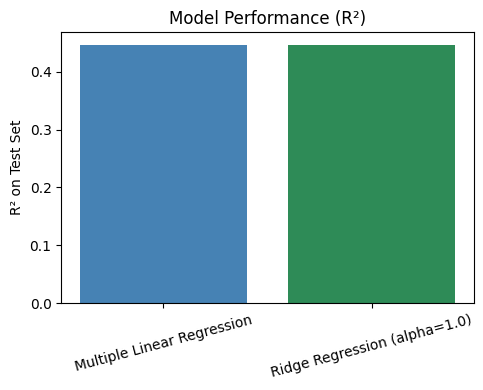

In [9]:
# ===============================================
# TASK 3: MODEL EVALUATION (TEST SET)
# ===============================================

def evaluate_model(name, model, X_test, y_test):
    """Compute standard regression metrics."""
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n{name} Performance on Test Set")
    print("-" * 40)
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R²  :", r2)
    
    return {
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

results = []
results.append(evaluate_model("Multiple Linear Regression", lin_reg, X_test, y_test))
results.append(evaluate_model("Ridge Regression (alpha=1.0)", ridge_model, X_test, y_test))

results_df = pd.DataFrame(results)
display(results_df)

# Simple R² comparison plot
plt.figure(figsize=(5,4))
plt.bar(results_df["Model"], results_df["R2"], color=["steelblue", "seagreen"])
plt.ylabel("R² on Test Set")
plt.title("Model Performance (R²)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



Multiple Linear Regression Cross-Validation (5-fold)
----------------------------------------
R² per fold: [0.44591839 0.26283206 0.45650175 0.53822172 0.4572965 ]
Mean R²: 0.43215408299312585
RMSE per fold: [ 777.40660338 1051.06637103 1027.81319368  861.92884138 1706.72146234]
Mean RMSE: 1084.987294363884

Ridge Regression (alpha=1.0) Cross-Validation (5-fold)
----------------------------------------
R² per fold: [0.44591839 0.26283205 0.45650175 0.53822172 0.4572965 ]
Mean R²: 0.43215408264328775
RMSE per fold: [ 777.40660168 1051.06637629 1027.81319357  861.92884148 1706.72145736]
Mean RMSE: 1084.9872940731877


,Model,CV_Mean_R2,CV_Mean_RMSE
0,Multiple Linear Regression,0.432154,1084.987294
1,Ridge Regression (alpha=1.0),0.432154,1084.987294


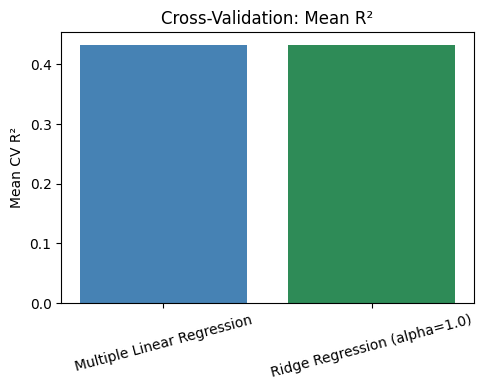

In [10]:
# ===============================================
# TASK 4: CROSS-VALIDATION (GENERALIZATION)
# ===============================================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cross_validate_model(name, model, X, y):
    """5-fold cross-validation with R² and RMSE."""
    cv_r2 = cross_val_score(model, X, y, cv=kf, scoring="r2")
    cv_neg_mse = cross_val_score(model, X, y, cv=kf, scoring="neg_mean_squared_error")
    cv_rmse = np.sqrt(-cv_neg_mse)
    
    print(f"\n{name} Cross-Validation (5-fold)")
    print("-" * 40)
    print("R² per fold:", cv_r2)
    print("Mean R²:", cv_r2.mean())
    print("RMSE per fold:", cv_rmse)
    print("Mean RMSE:", cv_rmse.mean())
    
    return {
        "Model": name,
        "CV_Mean_R2": cv_r2.mean(),
        "CV_Mean_RMSE": cv_rmse.mean()
    }

cv_results = []
cv_results.append(cross_validate_model("Multiple Linear Regression", lin_reg, X, y))
cv_results.append(cross_validate_model("Ridge Regression (alpha=1.0)", ridge_model, X, y))

cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df)

# Plot mean CV R²
plt.figure(figsize=(5,4))
plt.bar(cv_results_df["Model"], cv_results_df["CV_Mean_R2"], color=["steelblue", "seagreen"])
plt.ylabel("Mean CV R²")
plt.title("Cross-Validation: Mean R²")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
